In [308]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt



In [309]:
df = pd.read_csv("hospital_data.csv")

print(df.head())
print(df.info())


   patient_id    patient_name   age  gender   department  visit_date  \
0         301    kwame asante  34.0    Male   Cardiology  2025-01-15   
1         302  AKOSUA  MENSAH  28.0       f   pediatrics  2025-02-03   
2         303     Yaw Boateng  45.0    MALE  ORTHOPEDICS  2025-01-22   
3         304       Ama Owusu   NaN  Female      General  15/03/2025   
4         305      KOFI DARKO  67.0       M   cardiology  2025-02-18   

  blood_pressure weight_kg consultation_fee  satisfaction_score  \
0         120/80     75 kg          GHS 150                 8.0   
1         110/70      62kg          GHS 100                 9.0   
2         140/90     88 KG          GHS 200                 NaN   
3         130/85     70 kg          GHS 150                 7.0   
4        180/110      95kg          GHS 250                 6.0   

   wait_time_min      city insurance  
0           25.0     Accra       Yes  
1           15.0    kumasi        no  
2           45.0      TEMA       YES  
3       

In [310]:
df.columns = df.columns.str.strip().str.lower()

print(df.columns)

Index(['patient_id', 'patient_name', 'age', 'gender', 'department',
       'visit_date', 'blood_pressure', 'weight_kg', 'consultation_fee',
       'satisfaction_score', 'wait_time_min', 'city', 'insurance'],
      dtype='str')


In [311]:
df = df.drop_duplicates()

print(df.shape)

(35, 13)


In [312]:
df["patient_name"] = df["patient_name"].str.strip()

df["patient_name"] = df["patient_name"].str.title()

print(df["patient_name"].head())

0      Kwame Asante
1    Akosua  Mensah
2       Yaw Boateng
3         Ama Owusu
4        Kofi Darko
Name: patient_name, dtype: str


In [313]:
df["gender"] = df["gender"].str.strip().str.upper()

df["gender"] = df["gender"].replace({
    "M": "Male",
    "MALE": "Male",
    "F": "Female",
    "FEMALE": "Female"
})

print(df["gender"].value_counts())

gender
Male      18
Female    17
Name: count, dtype: int64


In [314]:
df["department"] = df["department"].str.strip().str.title()

print(df["department"].unique())


<StringArray>
['Cardiology', 'Pediatrics', 'Orthopedics', 'General']
Length: 4, dtype: str


In [315]:
df["city"] = df["city"].str.strip().str.title()

print(df["city"].unique())

<StringArray>
['Accra', 'Kumasi', 'Tema', 'Takoradi']
Length: 4, dtype: str


In [316]:
df["insurance"] = df["insurance"].str.strip().str.title()

print(df["insurance"].value_counts())

insurance
Yes    18
No     17
Name: count, dtype: int64


In [317]:
df["consultation_fee"] = (
    df["consultation_fee"]
    .astype(str)
    .str.replace("GHS", "", regex=False)
    .str.strip()
)

df["consultation_fee"] = pd.to_numeric(
    df["consultation_fee"],
    errors="coerce"
)

print(df["consultation_fee"].head())

0    150
1    100
2    200
3    150
4    250
Name: consultation_fee, dtype: int64


In [318]:
df["weight_kg"] = (
    df["weight_kg"]
    .astype(str)
    .str.replace("kg", "", case=False, regex=False)
    .str.strip()
)

df["weight_kg"] = pd.to_numeric(
    df["weight_kg"],
    errors="coerce"
)

print(df["weight_kg"].head())

0    75
1    62
2    88
3    70
4    95
Name: weight_kg, dtype: int64


In [319]:
df["age"] = pd.to_numeric(df["age"], errors="coerce")

print(df["age"].head())

0    34.0
1    28.0
2    45.0
3     NaN
4    67.0
Name: age, dtype: float64


In [320]:
df["wait_time_min"] = pd.to_numeric(
    df["wait_time_min"],
    errors="coerce"
)
print(df["wait_time_min"].head())

0    25.0
1    15.0
2    45.0
3     NaN
4    60.0
Name: wait_time_min, dtype: float64


In [321]:
df["satisfaction_score"] = pd.to_numeric(
    df["satisfaction_score"],
    errors="coerce"
)

In [322]:
df["visit_date"] = pd.to_datetime(
    df["visit_date"],
    errors="coerce",
    dayfirst=True
)

print(df["visit_date"].head())

0   2025-01-15
1   2025-02-03
2   2025-01-22
3          NaT
4   2025-02-18
Name: visit_date, dtype: datetime64[us]


C:\Users\HP\AppData\Local\Temp\ipykernel_14132\504823878.py:1: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df["visit_date"] = pd.to_datetime(


In [323]:
df["month"] = df["visit_date"].dt.month_name()

print(df["month"].head())

0     January
1    February
2     January
3         NaN
4    February
Name: month, dtype: str


In [324]:
bp_split = df["blood_pressure"].str.split("/", expand=True)

df["systolic_bp"] = pd.to_numeric(bp_split[0], errors="coerce")

df["diastolic_bp"] = pd.to_numeric(bp_split[1], errors="coerce")

print(df[["systolic_bp", "diastolic_bp"]].head())

   systolic_bp  diastolic_bp
0        120.0          80.0
1        110.0          70.0
2        140.0          90.0
3        130.0          85.0
4        180.0         110.0


In [325]:
print(df.isnull().sum())

patient_id             0
patient_name           0
age                    6
gender                 0
department             0
visit_date            17
blood_pressure         4
weight_kg              0
consultation_fee       0
satisfaction_score     7
wait_time_min          6
city                   0
insurance              0
month                 17
systolic_bp            4
diastolic_bp           4
dtype: int64


In [326]:
df["age"] = df["age"].fillna(df["age"].median())

df["wait_time_min"] = df["wait_time_min"].fillna(
    df["wait_time_min"].median()
)

df["satisfaction_score"] = df["satisfaction_score"].fillna(
    df["satisfaction_score"].median()
)

In [327]:
print(df.info())

print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 35 entries, 0 to 34
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   patient_id          35 non-null     int64         
 1   patient_name        35 non-null     str           
 2   age                 35 non-null     float64       
 3   gender              35 non-null     str           
 4   department          35 non-null     str           
 5   visit_date          18 non-null     datetime64[us]
 6   blood_pressure      31 non-null     str           
 7   weight_kg           35 non-null     int64         
 8   consultation_fee    35 non-null     int64         
 9   satisfaction_score  35 non-null     float64       
 10  wait_time_min       35 non-null     float64       
 11  city                35 non-null     str           
 12  insurance           35 non-null     str           
 13  month               18 non-null     str           
 14  systoli

In [328]:
avg_fee = df.groupby("department")["consultation_fee"].mean()

print(avg_fee)


department
Cardiology     220.000000
General        161.111111
Orthopedics    200.000000
Pediatrics     100.000000
Name: consultation_fee, dtype: float64


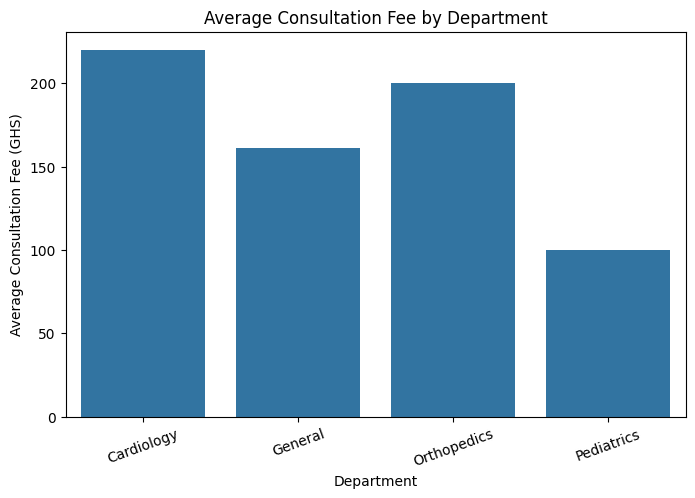

In [329]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=avg_fee.index,
    y=avg_fee.values
)

plt.title("Average Consultation Fee by Department")

plt.xlabel("Department")

plt.ylabel("Average Consultation Fee (GHS)")

plt.xticks(rotation=20)

plt.show()

In [330]:
print(avg_fee.idxmax())

Cardiology


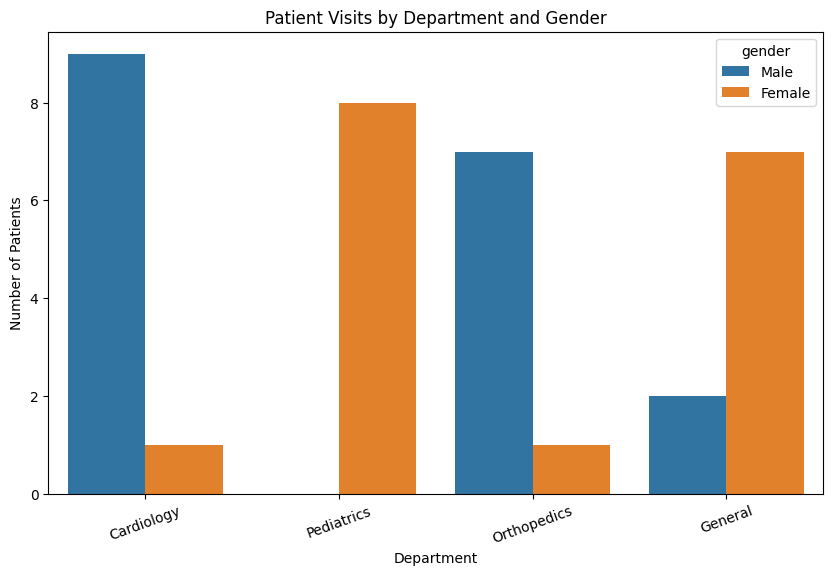

In [331]:
plt.figure(figsize=(10,6))

sns.countplot(
    data=df,
    x="department",
    hue="gender"
)

plt.title("Patient Visits by Department and Gender")

plt.xlabel("Department")

plt.ylabel("Number of Patients")

plt.xticks(rotation=20)

plt.show()

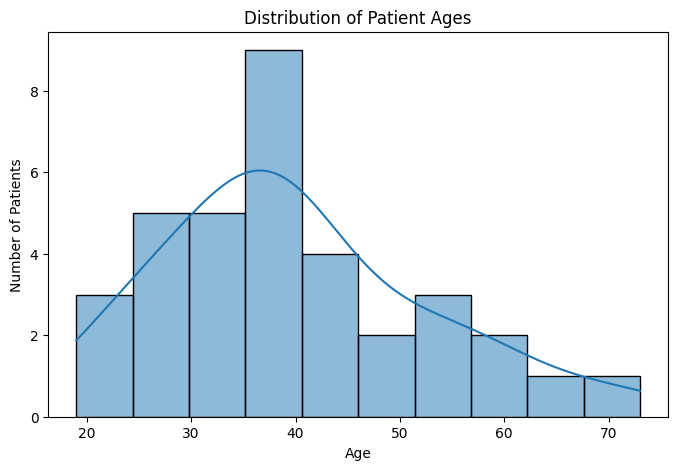

In [332]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="age",
    bins=10,
    kde=True
)

plt.title("Distribution of Patient Ages")

plt.xlabel("Age")

plt.ylabel("Number of Patients")

plt.show()

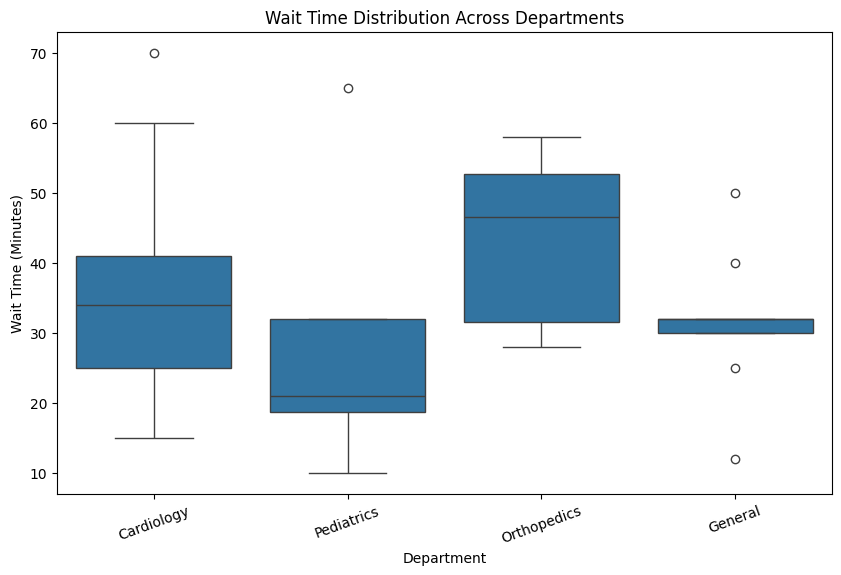

In [333]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=df,
    x="department",
    y="wait_time_min"
)

plt.title("Wait Time Distribution Across Departments")

plt.xlabel("Department")

plt.ylabel("Wait Time (Minutes)")

plt.xticks(rotation=20)

plt.show()

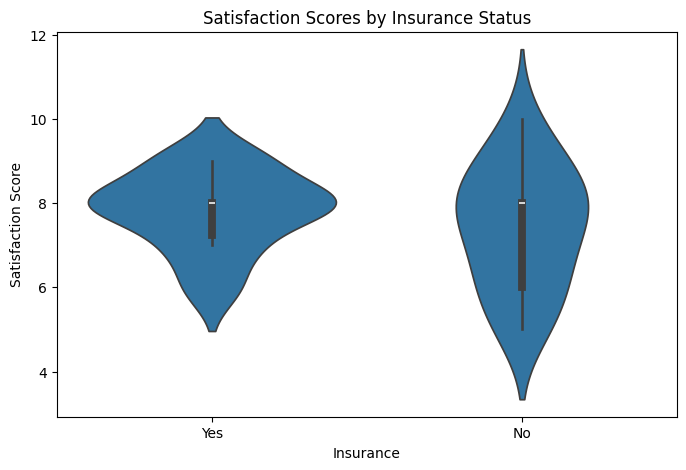

In [334]:
plt.figure(figsize=(8,5))

sns.violinplot(
    data=df,
    x="insurance",
    y="satisfaction_score"
)

plt.title("Satisfaction Scores by Insurance Status")

plt.xlabel("Insurance")

plt.ylabel("Satisfaction Score")

plt.show()

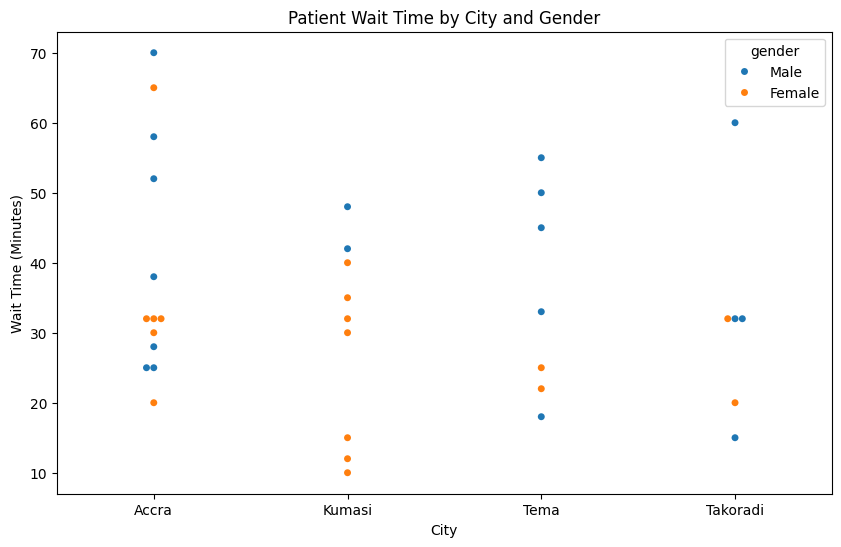

In [335]:
plt.figure(figsize=(10,6))

sns.swarmplot(
    data=df,
    x="city",
    y="wait_time_min",
    hue="gender"
)

plt.title("Patient Wait Time by City and Gender")

plt.xlabel("City")

plt.ylabel("Wait Time (Minutes)")

plt.show()

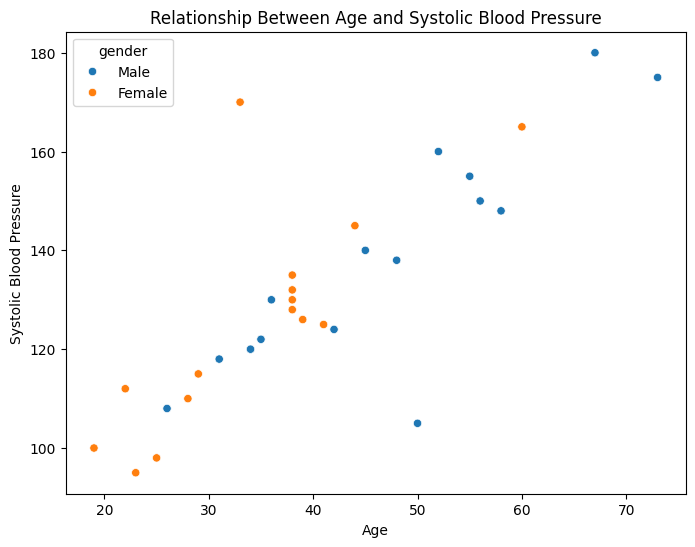

In [336]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="age",
    y="systolic_bp",
    hue="gender"
)

plt.title("Relationship Between Age and Systolic Blood Pressure")

plt.xlabel("Age")

plt.ylabel("Systolic Blood Pressure")

plt.show()

In [337]:
numeric_df = df.select_dtypes(include=["number"])

print(numeric_df.head())

   patient_id   age  weight_kg  consultation_fee  satisfaction_score  \
0         301  34.0         75               150                 8.0   
1         302  28.0         62               100                 9.0   
2         303  45.0         88               200                 8.0   
3         304  38.0         70               150                 7.0   
4         305  67.0         95               250                 6.0   

   wait_time_min  systolic_bp  diastolic_bp  
0           25.0        120.0          80.0  
1           15.0        110.0          70.0  
2           45.0        140.0          90.0  
3           32.0        130.0          85.0  
4           60.0        180.0         110.0  


In [338]:
corr_matrix = numeric_df.corr()

print(corr_matrix)

                    patient_id       age  weight_kg  consultation_fee  \
patient_id            1.000000 -0.011108  -0.131394          0.137272   
age                  -0.011108  1.000000   0.728148          0.376244   
weight_kg            -0.131394  0.728148   1.000000          0.383609   
consultation_fee      0.137272  0.376244   0.383609          1.000000   
satisfaction_score   -0.150570 -0.755109  -0.631521         -0.466069   
wait_time_min         0.057228  0.968531   0.725257          0.344431   
systolic_bp           0.013389  0.820654   0.909873          0.334946   
diastolic_bp          0.020256  0.797611   0.914610          0.319243   

                    satisfaction_score  wait_time_min  systolic_bp  \
patient_id                   -0.150570       0.057228     0.013389   
age                          -0.755109       0.968531     0.820654   
weight_kg                    -0.631521       0.725257     0.909873   
consultation_fee             -0.466069       0.344431     0.33

In [339]:
df["month"] = df["visit_date"].dt.month_name()
print(df["month"].head())

0     January
1    February
2     January
3         NaN
4    February
Name: month, dtype: str


In [340]:
monthly_wait = df.groupby("month")["wait_time_min"].mean()

print(monthly_wait)

month
April       41.5
February    34.8
January     31.0
March       44.0
Name: wait_time_min, dtype: float64


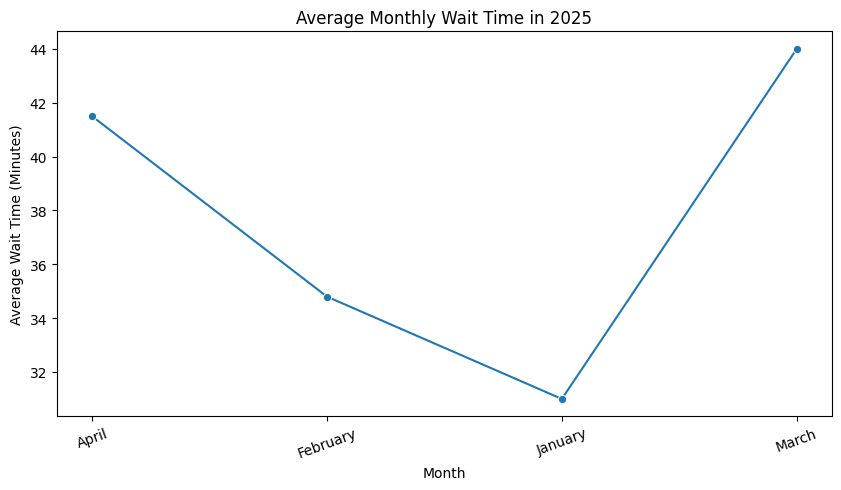

In [341]:
plt.figure(figsize=(10,5))

sns.lineplot(
    x=monthly_wait.index,
    y=monthly_wait.values,
    marker="o"
)

plt.title("Average Monthly Wait Time in 2025")

plt.xlabel("Month")

plt.ylabel("Average Wait Time (Minutes)")

plt.xticks(rotation=20)

plt.show()

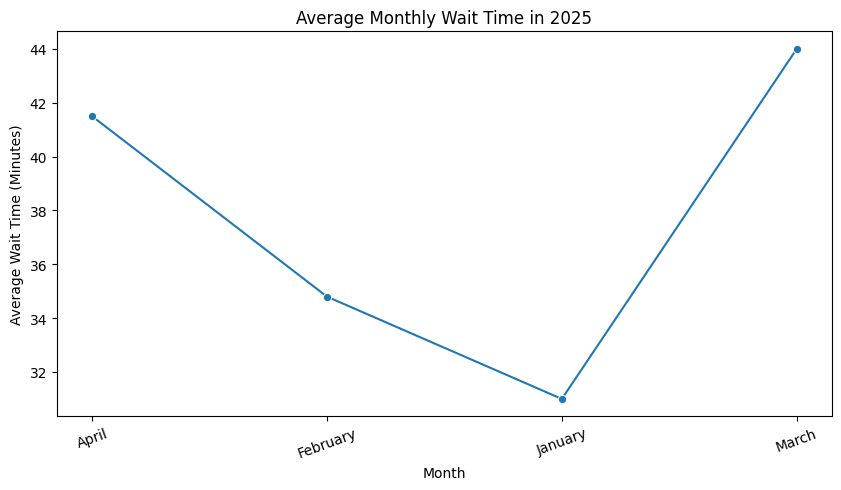

In [342]:
plt.figure(figsize=(10,5))

sns.lineplot(
    x=monthly_wait.index,
    y=monthly_wait.values,
    marker="o"
)

plt.title("Average Monthly Wait Time in 2025")

plt.xlabel("Month")

plt.ylabel("Average Wait Time (Minutes)")

plt.xticks(rotation=20)

plt.show()

In [343]:
df["satisfaction_score"] = pd.to_numeric(
    df["satisfaction_score"],
    errors="coerce"
)


In [344]:
sns.violinplot(
    data=df,
    x="gender",
    y="satisfaction_score",
    ax=axes[0,1]
)

axes[0,1].set_title("Satisfaction Score by Gender")

plt.show()

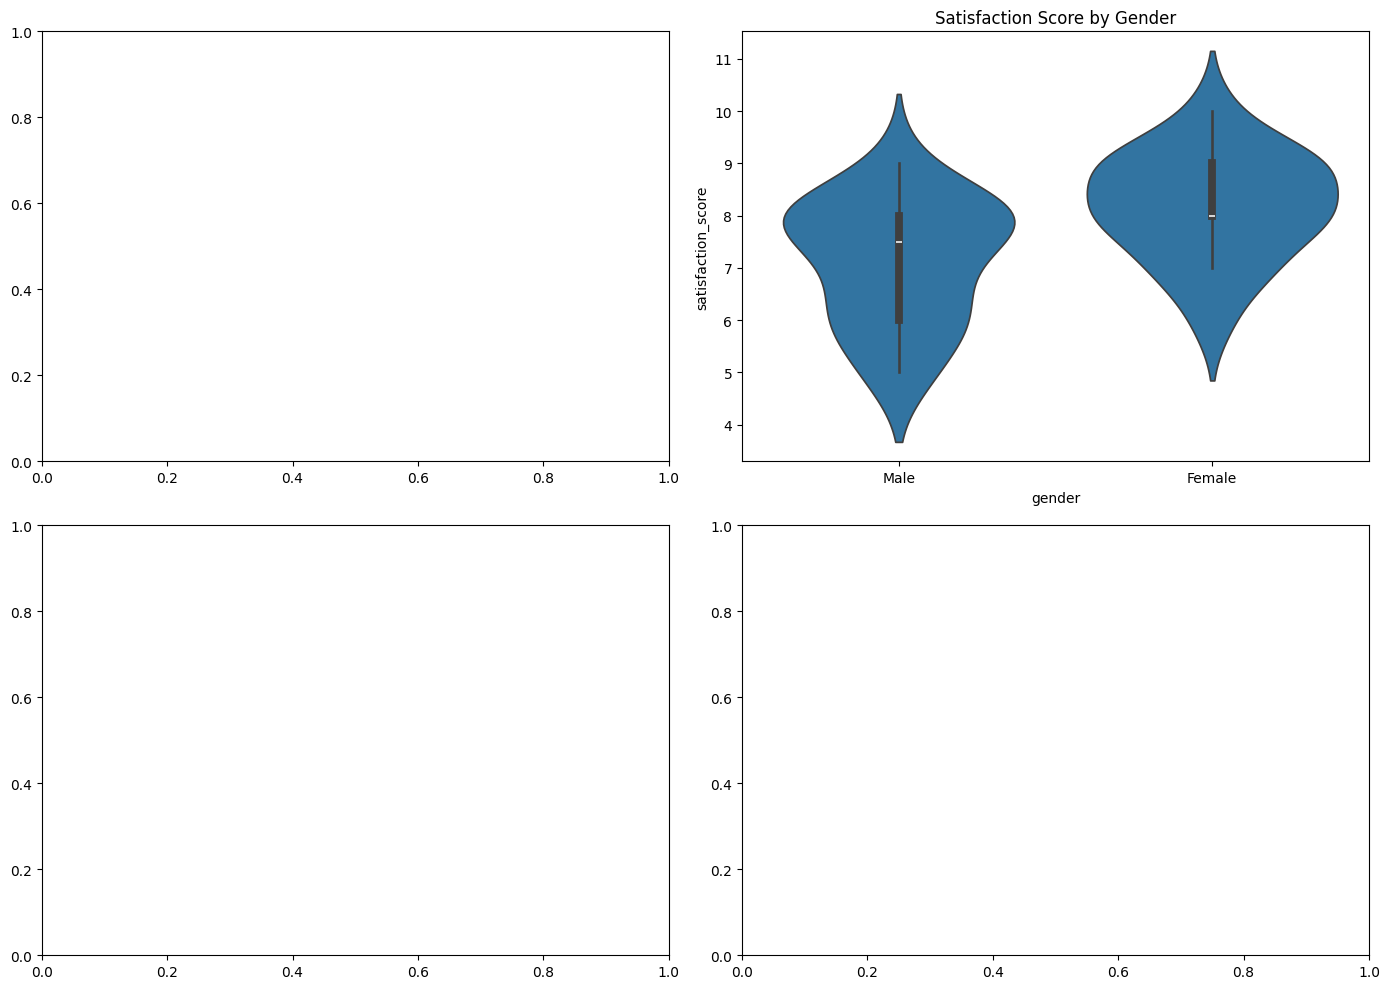

In [345]:
fig, axes = plt.subplots(2,2, figsize=(14,10))

sns.violinplot(
    data=df,
    x="gender",
    y="satisfaction_score",
    ax=axes[0,1]
)

axes[0,1].set_title("Satisfaction Score by Gender")

plt.tight_layout()
plt.show()

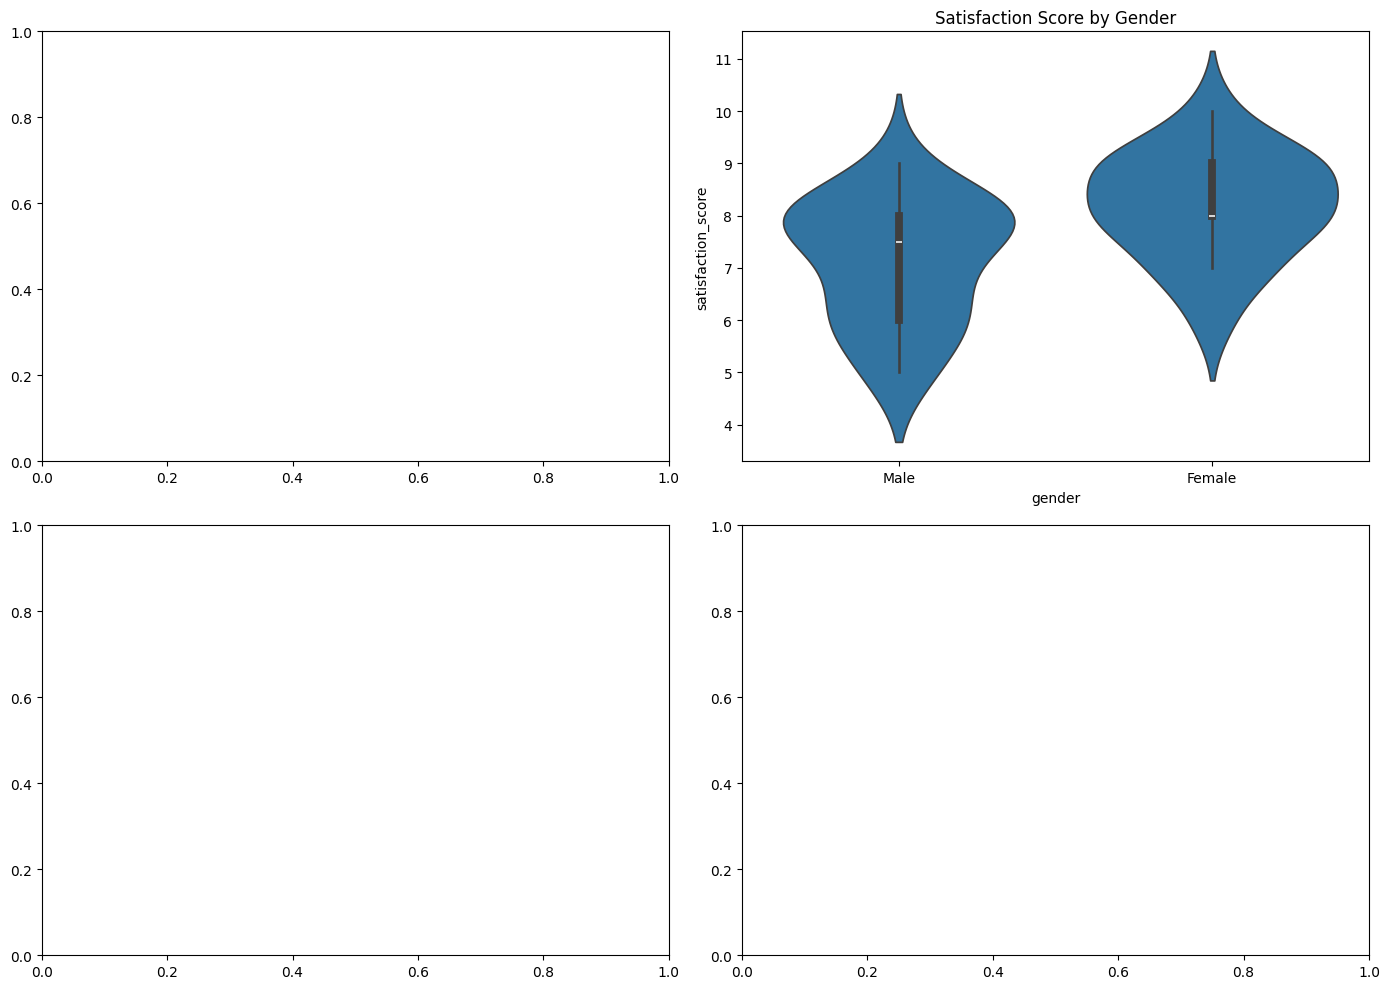

In [346]:
fig, axes = plt.subplots(2,2, figsize=(14,10))

sns.violinplot(
    data=df,
    x="gender",
    y="satisfaction_score",
    ax=axes[0,1]
)

axes[0,1].set_title("Satisfaction Score by Gender")

plt.tight_layout()
plt.show()

In [347]:
df["systolic_bp"] = df["blood_pressure"].str.split("/").str[0]

df["systolic_bp"] = pd.to_numeric(
    df["systolic_bp"],
    errors="coerce"
)

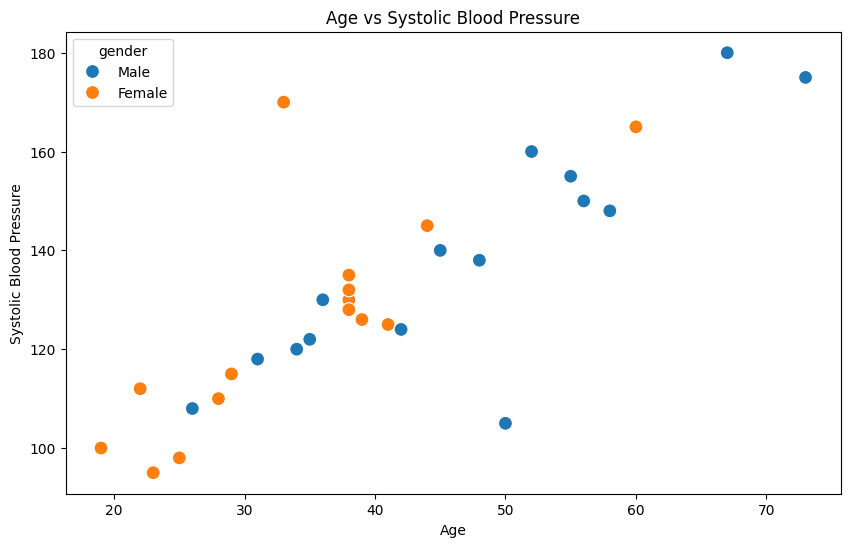

In [348]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="age",
    y="systolic_bp",
    hue="gender",
    s=100
)

plt.title("Age vs Systolic Blood Pressure")
plt.xlabel("Age")
plt.ylabel("Systolic Blood Pressure")

plt.show()

In [349]:
corr_matrix = numeric_df.corr()


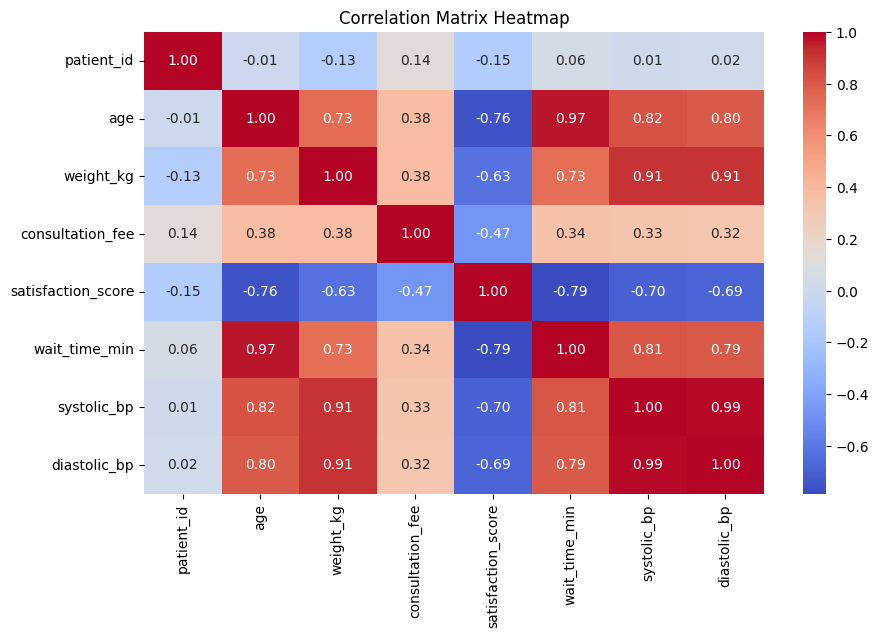

In [350]:
plt.figure(figsize=(10,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix Heatmap")

plt.show()

In [354]:
df["visit_date"] = pd.to_datetime(
    df["visit_date"],
    errors="coerce"
)


df["month"] = df["visit_date"].dt.month_name()
monthly_wait = df.groupby("month")["wait_time_min"].mean().reset_index()

month_order = [
    "January", "February", "March", "April", "May", "June","july", "August"]

monthly_wait=monthly_wait.sort_values("month")



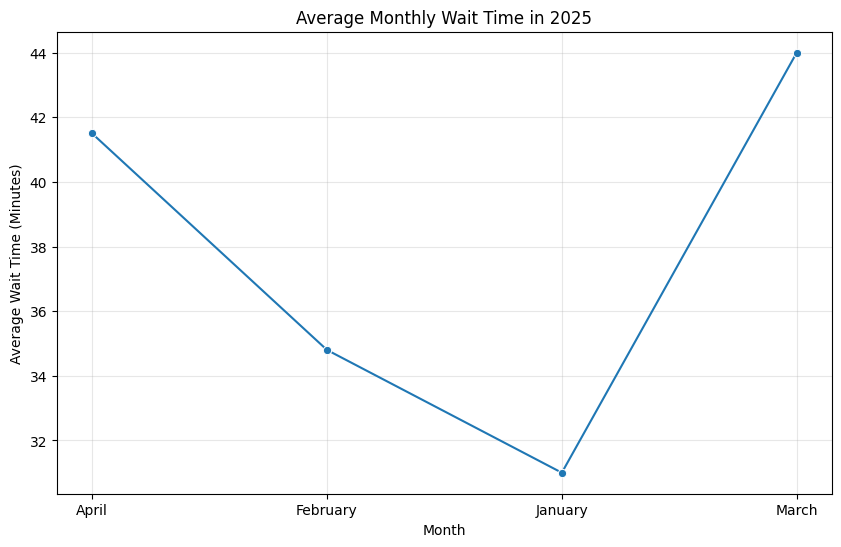

In [355]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=monthly_wait,
    x="month",
    y="wait_time_min",
    marker="o"
)

plt.title("Average Monthly Wait Time in 2025")
plt.xlabel("Month")
plt.ylabel("Average Wait Time (Minutes)")

plt.grid(alpha=0.3)

plt.show()

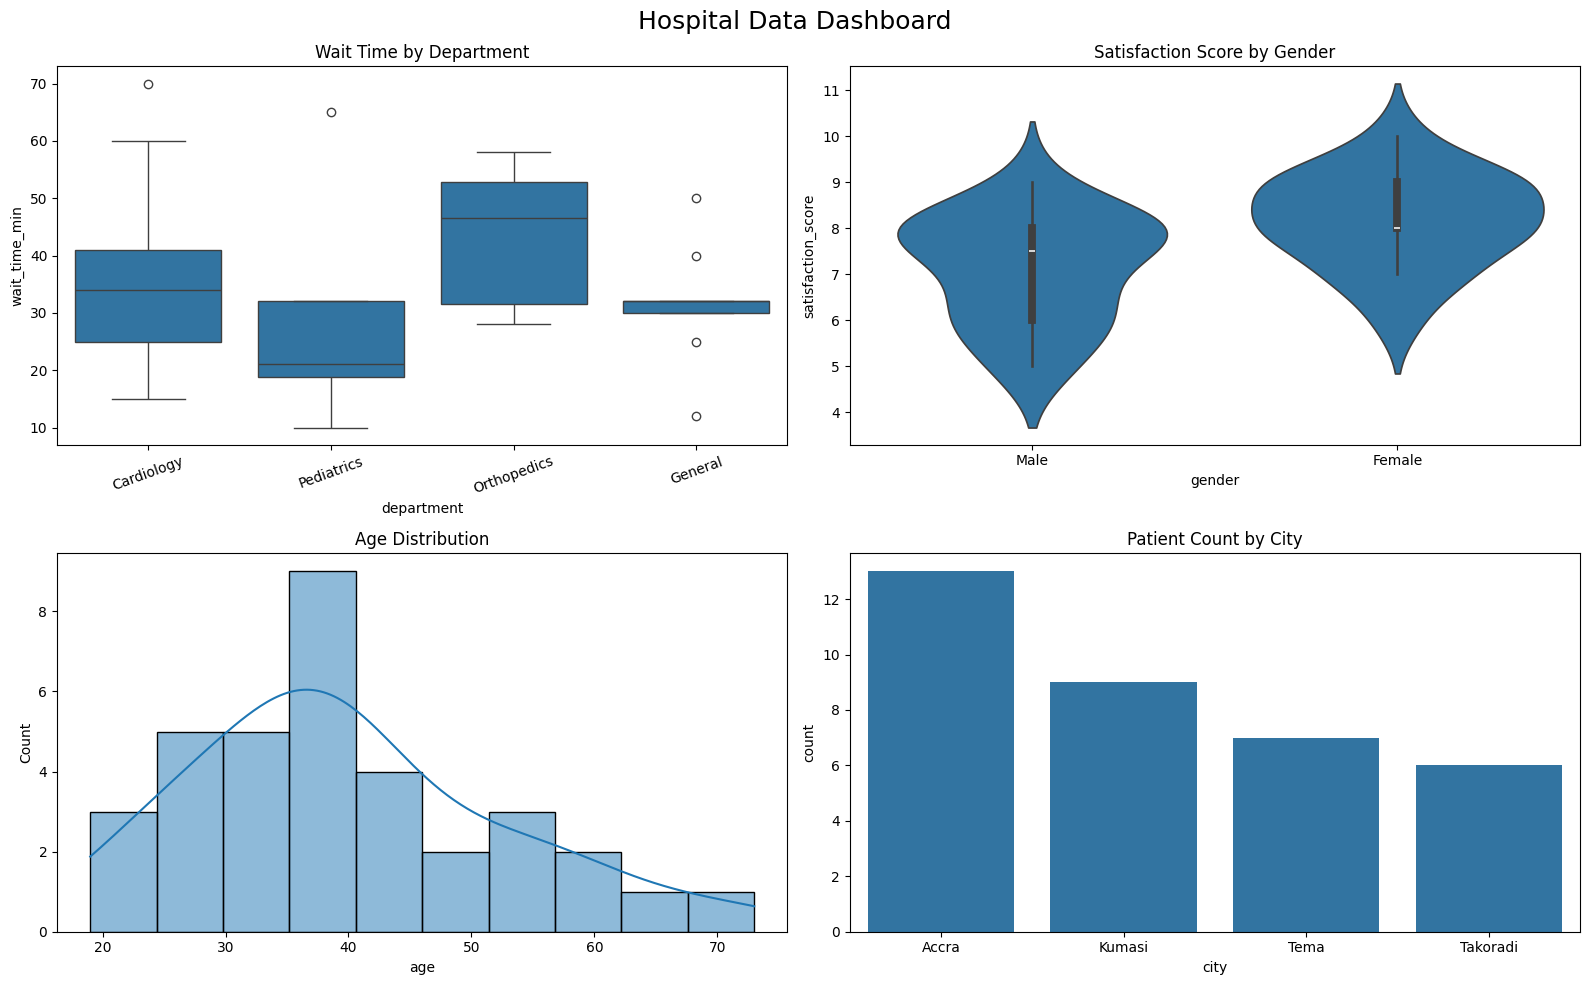

In [356]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# -----------------------------------
# 1. Wait Time by Department
# -----------------------------------

sns.boxplot(
    data=df,
    x="department",
    y="wait_time_min",
    ax=axes[0,0]
)

axes[0,0].set_title("Wait Time by Department")
axes[0,0].tick_params(axis='x', rotation=20)

# -----------------------------------
# 2. Satisfaction Score by Gender
# -----------------------------------

sns.violinplot(
    data=df,
    x="gender",
    y="satisfaction_score",
    ax=axes[0,1]
)

axes[0,1].set_title("Satisfaction Score by Gender")

# -----------------------------------
# 3. Age Distribution
# -----------------------------------

sns.histplot(
    data=df,
    x="age",
    bins=10,
    kde=True,
    ax=axes[1,0]
)

axes[1,0].set_title("Age Distribution")

# -----------------------------------
# 4. Patient Count by City
# -----------------------------------

sns.countplot(
    data=df,
    x="city",
    ax=axes[1,1]
)

axes[1,1].set_title("Patient Count by City")

# -----------------------------------
# Dashboard Layout
# -----------------------------------

plt.suptitle(
    "Hospital Data Dashboard",
    fontsize=18
)

plt.tight_layout()

plt.show()